# Introduction to data
## Package imports

In [ ]:
# numpy and pandas for data manipulation
import numpy as np
import dask.dataframe as dd
import pandas as pd

# sklearn preprocessing for dealing with categorical variables
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt

## Description of datasets

7 datasets:

* application_train/application_test: the main training and testing data with information about each loan application at Home Credit. Every loan has its own row and is identified by the feature `SK_ID_CURR`. The training application data comes with the `TARGET` indicating 0: the loan was repaid or 1: the loan was not repaid.
* bureau: data concerning client's previous credits from other financial institutions. Each previous credit has its own row in bureau, but one loan in the application data can have multiple previous credits.
* bureau_balance: monthly data about the previous credits in bureau. Each row is one month of a previous credit, and a single previous credit can have multiple rows, one for each month of the credit length. 
* previous_application: previous applications for loans at Home Credit of clients who have loans in the application data. Each current loan in the application data can have multiple previous loans. Each previous application has one row and is identified by the feature `SK_ID_PREV`. 
* POS_CASH_BALANCE: monthly data about previous point of sale or cash loans clients have had with Home Credit. Each row is one month of a previous point of sale or cash loan, and a single previous loan can have many rows.
* credit_card_balance: monthly data about previous credit cards clients have had with Home Credit. Each row is one month of a credit card balance, and a single credit card can have many rows.
* installments_payment: payment history for previous loans at Home Credit. There is one row for every made payment and one row for every missed payment. 

We will start with a quick analysis of each dataset.

# Dataset 1 application

In [2]:
# Training data
app_train = pd.read_csv('data/Projet+Mise+en+prod+-+home-credit-default-risk/application_train.csv')
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

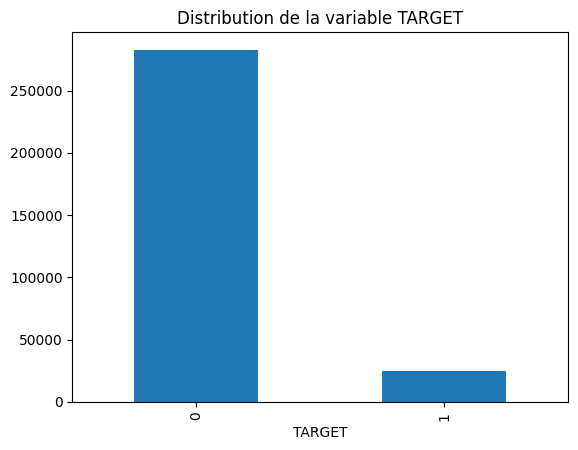

In [4]:
app_train['TARGET'].value_counts().plot(kind='bar')
plt.title('Distribution de la variable TARGET')
plt.show()


## Missing values

In [5]:
def missing_values_table(df):
    """
    Generates a summary table of missing values in a DataFrame.

    Parameters:
    df (pandas.DataFrame): The DataFrame to analyze for missing values.

    Returns:
    pandas.DataFrame: A table showing the number and percentage of missing values 
                      for each column in the DataFrame, sorted by percentage in descending order.
                      Only columns with at least one missing value are included.

    The function also prints a brief summary indicating the total number of columns 
    and how many of them contain missing values.
    """
    # Total missing values
    mis_val = df.isnull().sum()
    
    # Percentage of missing values
    mis_val_percent = 100 * mis_val / len(df)
    
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    
    # Print some summary information
    print(f"Your selected dataframe has {df.shape[1]} columns.\n"      
          f"There are {mis_val_table_ren_columns.shape[0]} columns that have missing values.")
    
    return mis_val_table_ren_columns


In [6]:
# Missing values statistics for train
missing_values = missing_values_table(app_train)
missing_values.head(20)

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


## Column types

In [7]:
# Number of each type of column
app_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

## Duplicates

In [8]:
def check_duplicates(data_set, subset=None, keep='first'):
    """
    Identifies and displays duplicate rows in a DataFrame based on specified columns.

    Parameters:
    data_set (pandas.DataFrame): The DataFrame to check for duplicates.
    subset (list or str, optional): Column label or sequence of labels to consider 
                                    for identifying duplicates. Defaults to None, 
                                    meaning all columns are used.
    keep (str, optional): Determines which duplicates (if any) to mark as duplicates:
                          - 'first': Mark duplicates except for the first occurrence.
                          - 'last': Mark duplicates except for the last occurrence.
                          - False: Mark all duplicates.
                          Defaults to 'first'.

    Returns:
    pandas.DataFrame: A DataFrame containing the duplicate rows found.

    The function also prints:
    - The total number of rows,
    - The number of unique rows (after removing duplicates),
    - The number of duplicated rows,
    - The duplicated rows themselves (if any).
    """
    # Identify duplicates
    doublons = data_set[data_set.duplicated(subset=subset, keep=keep)]

    # Display the results
    nombre_total = len(data_set)
    nombre_uniques = len(data_set.drop_duplicates(subset=subset, keep=keep))
    nombre_doublons = len(doublons)

    print(f"Total number of lines : {nombre_total}")
    print(f"Number of unique lines : {nombre_uniques}")
    print(f"Number of lines duplicated : {nombre_doublons}")

    if nombre_doublons > 0:
        print("\nDuplicate rows :")
        print(doublons)

    return doublons


In [9]:
check_duplicates(app_train)

Total number of lines : 307511
Number of unique lines : 307511
Number of lines duplicated : 0


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR


## Qualitative values

In [10]:
# Number of unique classes in each object column
unique_counts = app_train.select_dtypes('object').nunique()
print(unique_counts)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64


# Dataset 2 bureau

In [11]:
# Bureau data
bureau = pd.read_csv('data/Projet+Mise+en+prod+-+home-credit-default-risk/bureau.csv')
print('Bureau data shape: ', bureau.shape)
bureau.head()

Bureau data shape:  (1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


## Column types

In [12]:
# Number of each type of column
bureau.dtypes.value_counts()

float64    8
int64      6
object     3
Name: count, dtype: int64

## Duplicates

In [13]:
check_duplicates(bureau,['SK_ID_CURR'])

Total number of lines : 1716428
Number of unique lines : 305811
Number of lines duplicated : 1410617

Duplicate rows :
         SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE CREDIT_CURRENCY  DAYS_CREDIT  \
1            215354       5714463        Active      currency 1         -208   
2            215354       5714464        Active      currency 1         -203   
3            215354       5714465        Active      currency 1         -203   
4            215354       5714466        Active      currency 1         -629   
5            215354       5714467        Active      currency 1         -273   
...             ...           ...           ...             ...          ...   
1716423      259355       5057750        Active      currency 1          -44   
1716424      100044       5057754        Closed      currency 1        -2648   
1716425      100044       5057762        Closed      currency 1        -1809   
1716426      246829       5057770        Closed      currency 1        -1878   
1

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.00,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN
5,215354,5714467,Active,currency 1,-273,0,27460.0,NaN,0.0,0,180000.00,71017.38,108982.62,0.0,Credit card,-31,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,11250.00,11250.00,0.00,0.0,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,38130.84,0.00,0.00,0.0,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,15570.00,NaN,NaN,0.0,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,36000.00,0.00,0.00,0.0,Consumer credit,-1508,NaN


## Qualitative values

In [14]:
# Number of unique classes in each object column
unique_counts = bureau.select_dtypes('object').nunique()
print(unique_counts)

CREDIT_ACTIVE       4
CREDIT_CURRENCY     4
CREDIT_TYPE        15
dtype: int64


## Missing values

In [15]:
missing_values = missing_values_table(bureau)
missing_values.head(20)

Your selected dataframe has 17 columns.
There are 7 columns that have missing values.


,Missing Values,% of Total Values
AMT_ANNUITY,1226791,71.5
AMT_CREDIT_MAX_OVERDUE,1124488,65.5
DAYS_ENDDATE_FACT,633653,36.9
AMT_CREDIT_SUM_LIMIT,591780,34.5
AMT_CREDIT_SUM_DEBT,257669,15.0
DAYS_CREDIT_ENDDATE,105553,6.1
AMT_CREDIT_SUM,13,0.0


# Dataset 3 bureau_balance

In [16]:
# Bureau_balance data
bureau_balance = pd.read_csv('data/Projet+Mise+en+prod+-+home-credit-default-risk/bureau_balance.csv')
print('Bureau_balance data shape: ', bureau_balance.shape)
bureau_balance.head()

Bureau_balance data shape:  (27299925, 3)


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


## Column types

In [17]:
# Number of each type of column
bureau_balance.dtypes

SK_ID_BUREAU       int64
MONTHS_BALANCE     int64
STATUS            object
dtype: object

## Duplicates

In [18]:
check_duplicates(bureau_balance)

Total number of lines : 27299925
Number of unique lines : 27299925
Number of lines duplicated : 0


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS


## Qualitative values

In [19]:
# Number of unique classes in each object column
unique_counts = bureau_balance.select_dtypes('object').nunique()
print(unique_counts)

STATUS    8
dtype: int64


## Missing values

In [20]:
missing_values = missing_values_table(bureau_balance)
missing_values.head(20)

Your selected dataframe has 3 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


# Dataset 4 previous_application

In [21]:
# Previous_application data
previous_app = pd.read_csv('data/Projet+Mise+en+prod+-+home-credit-default-risk/previous_application.csv')
print('Previous_application data shape: ', previous_app.shape)
previous_app.head()

Previous_application data shape:  (1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


## Column types

In [22]:
# Number of each type of column
previous_app.dtypes.value_counts()

object     16
float64    15
int64       6
Name: count, dtype: int64

## Duplicates

In [23]:
check_duplicates(previous_app, ['SK_ID_CURR'])

Total number of lines : 1670214
Number of unique lines : 338857
Number of lines duplicated : 1331357

Duplicate rows :
         SK_ID_PREV  SK_ID_CURR NAME_CONTRACT_TYPE  AMT_ANNUITY  \
23          1172937      302212         Cash loans    39475.305   
115         2686051      101529         Cash loans          NaN   
180         1630059      405785     Consumer loans     4550.535   
217         1129372      203250         Cash loans    31952.205   
262         2562544      163961         Cash loans    29527.200   
...             ...         ...                ...          ...   
1670209     2300464      352015     Consumer loans    14704.290   
1670210     2357031      334635     Consumer loans     6622.020   
1670211     2659632      249544     Consumer loans    11520.855   
1670212     2785582      400317         Cash loans    18821.520   
1670213     2418762      261212         Cash loans    16431.300   

         AMT_APPLICATION  AMT_CREDIT  AMT_DOWN_PAYMENT  AMT_GOODS_PRICE  \
2

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
23,1172937,302212,Cash loans,39475.305,1129500.0,1277104.5,NaN,1129500.0,THURSDAY,5,...,XNA,54.0,low_normal,Cash X-Sell: low,NaN,NaN,NaN,NaN,NaN,NaN
115,2686051,101529,Cash loans,NaN,0.0,0.0,NaN,NaN,TUESDAY,9,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
180,1630059,405785,Consumer loans,4550.535,28300.5,22617.0,6750.0,28300.5,FRIDAY,10,...,Connectivity,6.0,high,POS mobile with interest,365243.0,-2005.0,-1855.0,-1855.0,-1851.0,0.0
217,1129372,203250,Cash loans,31952.205,495000.0,553806.0,NaN,495000.0,THURSDAY,10,...,XNA,36.0,high,Cash X-Sell: high,365243.0,-829.0,221.0,-769.0,-765.0,1.0
262,2562544,163961,Cash loans,29527.200,270000.0,270000.0,0.0,270000.0,WEDNESDAY,12,...,Consumer electronics,12.0,high,Cash Street: high,365243.0,-2307.0,-1977.0,-1977.0,-1969.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,2300464,352015,Consumer loans,14704.290,267295.5,311400.0,0.0,267295.5,WEDNESDAY,12,...,Furniture,30.0,low_normal,POS industry with interest,365243.0,-508.0,362.0,-358.0,-351.0,0.0
1670210,2357031,334635,Consumer loans,6622.020,87750.0,64291.5,29250.0,87750.0,TUESDAY,15,...,Furniture,12.0,middle,POS industry with interest,365243.0,-1604.0,-1274.0,-1304.0,-1297.0,0.0
1670211,2659632,249544,Consumer loans,11520.855,105237.0,102523.5,10525.5,105237.0,MONDAY,12,...,Consumer electronics,10.0,low_normal,POS household with interest,365243.0,-1457.0,-1187.0,-1187.0,-1181.0,0.0
1670212,2785582,400317,Cash loans,18821.520,180000.0,191880.0,NaN,180000.0,WEDNESDAY,9,...,XNA,12.0,low_normal,Cash X-Sell: low,365243.0,-1155.0,-825.0,-825.0,-817.0,1.0


## Qualitative values

In [24]:
# Number of unique classes in each object column
unique_counts = previous_app.select_dtypes('object').nunique()
print(unique_counts)

NAME_CONTRACT_TYPE              4
WEEKDAY_APPR_PROCESS_START      7
FLAG_LAST_APPL_PER_CONTRACT     2
NAME_CASH_LOAN_PURPOSE         25
NAME_CONTRACT_STATUS            4
NAME_PAYMENT_TYPE               4
CODE_REJECT_REASON              9
NAME_TYPE_SUITE                 7
NAME_CLIENT_TYPE                4
NAME_GOODS_CATEGORY            28
NAME_PORTFOLIO                  5
NAME_PRODUCT_TYPE               3
CHANNEL_TYPE                    8
NAME_SELLER_INDUSTRY           11
NAME_YIELD_GROUP                5
PRODUCT_COMBINATION            17
dtype: int64


## Missing values

In [25]:
missing_values = missing_values_table(previous_app)
missing_values.head(20)

Your selected dataframe has 37 columns.
There are 16 columns that have missing values.


,Missing Values,% of Total Values
RATE_INTEREST_PRIVILEGED,1664263,99.6
RATE_INTEREST_PRIMARY,1664263,99.6
AMT_DOWN_PAYMENT,895844,53.6
RATE_DOWN_PAYMENT,895844,53.6
NAME_TYPE_SUITE,820405,49.1
DAYS_LAST_DUE,673065,40.3
DAYS_FIRST_DRAWING,673065,40.3
DAYS_FIRST_DUE,673065,40.3
DAYS_TERMINATION,673065,40.3
NFLAG_INSURED_ON_APPROVAL,673065,40.3


# Dataset 5 POS_CASH_balance

In [26]:
# POS_CASH_balance data
pos_cash_balance = pd.read_csv('data/Projet+Mise+en+prod+-+home-credit-default-risk/POS_CASH_balance.csv')
print('POS_CASH_balance data shape: ', pos_cash_balance.shape)
pos_cash_balance.head()

POS_CASH_balance data shape:  (10001358, 8)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


## Column types

In [27]:
# Number of each type of column
pos_cash_balance.dtypes.value_counts()

int64      5
float64    2
object     1
Name: count, dtype: int64

In [28]:
pos_cash_balance.dtypes

SK_ID_PREV                 int64
SK_ID_CURR                 int64
MONTHS_BALANCE             int64
CNT_INSTALMENT           float64
CNT_INSTALMENT_FUTURE    float64
NAME_CONTRACT_STATUS      object
SK_DPD                     int64
SK_DPD_DEF                 int64
dtype: object

## Duplicates

In [29]:
check_duplicates(pos_cash_balance)

Total number of lines : 10001358
Number of unique lines : 10001358
Number of lines duplicated : 0


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF


## Qualitative values

In [30]:
# Number of unique classes in each object column
unique_counts = pos_cash_balance.select_dtypes('object').nunique()
print(unique_counts)

NAME_CONTRACT_STATUS    9
dtype: int64


## Missing values

In [31]:
missing_values = missing_values_table(pos_cash_balance)
missing_values.head(20)

Your selected dataframe has 8 columns.
There are 2 columns that have missing values.


,Missing Values,% of Total Values
CNT_INSTALMENT_FUTURE,26087,0.3
CNT_INSTALMENT,26071,0.3


# Dataset 6 instalments_payments

In [32]:
# Instalments_payments data
inst_payments = pd.read_csv('data/Projet+Mise+en+prod+-+home-credit-default-risk/installments_payments.csv')
print('Instalments_payments data shape: ', inst_payments.shape)
inst_payments.head()

Instalments_payments data shape:  (13605401, 8)


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


## Column types

In [33]:
# Number of each type of column
inst_payments.dtypes.value_counts()

float64    5
int64      3
Name: count, dtype: int64

In [34]:
inst_payments.dtypes

SK_ID_PREV                  int64
SK_ID_CURR                  int64
NUM_INSTALMENT_VERSION    float64
NUM_INSTALMENT_NUMBER       int64
DAYS_INSTALMENT           float64
DAYS_ENTRY_PAYMENT        float64
AMT_INSTALMENT            float64
AMT_PAYMENT               float64
dtype: object

## Duplicates

In [35]:
check_duplicates(inst_payments)

Total number of lines : 13605401
Number of unique lines : 13605401
Number of lines duplicated : 0


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT


## Qualitative values

In [36]:
# Number of unique classes in each object column
unique_counts = inst_payments.select_dtypes('object').nunique()
print(unique_counts)

Series([], dtype: float64)


## Missing values

In [37]:
missing_values = missing_values_table(inst_payments)
missing_values.head(20)

Your selected dataframe has 8 columns.
There are 2 columns that have missing values.


,Missing Values,% of Total Values
DAYS_ENTRY_PAYMENT,2905,0.0
AMT_PAYMENT,2905,0.0


# Dataset 7 credit_card_balance

In [38]:
# Credit_card_balance data
credit_card = pd.read_csv('data/Projet+Mise+en+prod+-+home-credit-default-risk/credit_card_balance.csv')
print('Credit_card_balance data shape: ', credit_card.shape)
credit_card.head()

Credit_card_balance data shape:  (3840312, 23)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


## Column types

In [39]:
# Number of each type of column
credit_card.dtypes.value_counts()

float64    15
int64       7
object      1
Name: count, dtype: int64

## Duplicates

In [40]:
check_duplicates(credit_card)

Total number of lines : 3840312
Number of unique lines : 3840312
Number of lines duplicated : 0


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF


## Qualitative values

In [41]:
# Number of unique classes in each object column
unique_counts = credit_card.select_dtypes('object').nunique()
print(unique_counts)

NAME_CONTRACT_STATUS    7
dtype: int64


## Missing values

In [42]:
missing_values = missing_values_table(credit_card)
missing_values.head(20)

Your selected dataframe has 23 columns.
There are 9 columns that have missing values.


,Missing Values,% of Total Values
AMT_PAYMENT_CURRENT,767988,20.0
AMT_DRAWINGS_ATM_CURRENT,749816,19.5
AMT_DRAWINGS_OTHER_CURRENT,749816,19.5
AMT_DRAWINGS_POS_CURRENT,749816,19.5
CNT_DRAWINGS_ATM_CURRENT,749816,19.5
CNT_DRAWINGS_POS_CURRENT,749816,19.5
CNT_DRAWINGS_OTHER_CURRENT,749816,19.5
AMT_INST_MIN_REGULARITY,305236,7.9
CNT_INSTALMENT_MATURE_CUM,305236,7.9


# Encoding

In [ ]:
def process_categorical_columns(df, verbose=True, nan_as_category=True):
    """
    Process categorical columns:
    1. Apply LabelEncoder to columns with 2 or fewer unique values
    2. Apply one-hot encoding to columns with 3 or more unique values
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataset to be processed
    verbose : bool, default=True
        Whether to print the number of encoded columns
    nan_as_category : bool, default=False
        If True, include NaN values as a separate category in one-hot encoding
        
    Returns:
    --------
    pandas DataFrame
        The processed dataset with all categorical columns encoded
    """
    # Store original shape
    original_shape = df.shape
    
    # Keep original columns to identify new ones created by one-hot encoding
    original_columns = list(df.columns)
    
    # Process columns with Label Encoder (2 or fewer unique values)
    le = LabelEncoder()
    le_count = 0
    
    for col in df.columns:
        if df[col].dtype == 'object' and df[col].nunique() < 3:
            # Make sure the values are strings before encoding
            df[col] = df[col].astype(str)
            
            # Apply encoding with loc to ensure change in place
            df.loc[:, col] = le.fit_transform(df[col])
            
            le_count += 1
    
    # Process columns with one-hot encoding (3 or more unique values)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object' and df[col].nunique() >= 3]
    ohe_count = len(categorical_columns)
    
    # Apply one-hot encoding
    if ohe_count > 0:
        df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    
    # Calculate new columns created by one-hot encoding
    new_columns = [col for col in df.columns if col not in original_columns]
    
    # Get new shape
    new_shape = df.shape
    
    if verbose:
        print(f"Original shape: {original_shape}")
        print(f"{le_count} columns have been encoded with LabelEncoder.")
        print(f"{ohe_count} columns have been encoded with One-Hot Encoding.")
        print(f"{len(new_columns)} new columns have been created with One-Hot Encoding.")
        print(f"Nouveau shape: {new_shape}")
    
    return df

print('app_train')
app_train_encoded = process_categorical_columns(app_train)
print('bureau')
bureau_encoded = process_categorical_columns(bureau)
print('bureau_balance')
bureau_balance_encoded = process_categorical_columns(bureau_balance)
print('previous_app')
previous_app_encoded = process_categorical_columns(previous_app)
print('pos_cash_balance')
pos_cash_balance_encoded = process_categorical_columns(pos_cash_balance)
print('inst_payments')
inst_payments_encoded = process_categorical_columns(inst_payments)
print('credit_card')
credit_card_encoded = process_categorical_columns(credit_card)


app_train
Original shape: (307511, 122)
4 columns have been encoded with LabelEncoder.
13 columns have been encoded with One-Hot Encoding.
148 new columns have been created with One-Hot Encoding.
Nouveau shape: (307511, 257)
bureau
Original shape: (1716428, 17)
0 columns have been encoded with LabelEncoder.
3 columns have been encoded with One-Hot Encoding.
26 new columns have been created with One-Hot Encoding.
Nouveau shape: (1716428, 40)
bureau_balance
Original shape: (27299925, 3)
0 columns have been encoded with LabelEncoder.
1 columns have been encoded with One-Hot Encoding.
9 new columns have been created with One-Hot Encoding.
Nouveau shape: (27299925, 11)
previous_app
Original shape: (1670214, 37)
1 columns have been encoded with LabelEncoder.
15 columns have been encoded with One-Hot Encoding.
156 new columns have been created with One-Hot Encoding.
Nouveau shape: (1670214, 178)
pos_cash_balance
Original shape: (10001358, 8)
0 columns have been encoded with LabelEncoder.
1 co

In [45]:
print('app_train original shape: ', app_train.shape)
print('app_train shape after encoding: ', app_train_encoded.shape)

print('bureau original shape: ', bureau.shape)
print('bureau shape after  encoding: ', bureau_encoded.shape)

print('bureau_balance original shape: ', bureau_balance.shape)
print('bureau_balance shape after  encoding: ', bureau_balance_encoded.shape)

print('previous_app original shape: ', previous_app.shape)
print('previous_app shape after  encoding: ', previous_app_encoded.shape)

print('pos_cash_balance original shape: ', pos_cash_balance.shape)
print('pos_cash_balance shape after  encoding: ', pos_cash_balance_encoded.shape)

print('inst_payments original shape: ', inst_payments.shape)
print('inst_payments shape after  encoding: ', inst_payments_encoded.shape)

print('credit_card original shape: ', credit_card.shape)
print('credit_card shape after  encoding: ', credit_card_encoded.shape)

app_train original shape:  (307511, 122)
app_train shape after encoding:  (307511, 257)
bureau original shape:  (1716428, 17)
bureau shape after  encoding:  (1716428, 40)
bureau_balance original shape:  (27299925, 3)
bureau_balance shape after  encoding:  (27299925, 11)
previous_app original shape:  (1670214, 37)
previous_app shape after  encoding:  (1670214, 178)
pos_cash_balance original shape:  (10001358, 8)
pos_cash_balance shape after  encoding:  (10001358, 17)
inst_payments original shape:  (13605401, 8)
inst_payments shape after  encoding:  (13605401, 8)
credit_card original shape:  (3840312, 23)
credit_card shape after  encoding:  (3840312, 30)


# Managing data types

In [48]:
def optimize_numeric_dtypes(df, verbose=False):
    """
    Converts numeric columns to their smallest possible data types to reduce memory usage.
    
    Parameters:
    -----------
    df (pd.DataFrame): Input Pandas DataFrame
    verbose (bool): Whether to print optimization results
    
    Returns:
    --------
    pd.DataFrame: DataFrame with memory-optimized columns
    """
    original_memory = df.memory_usage(deep=True).sum() / 1024**2  # Memory in MB
    
    # Track conversions for reporting
    int_conversions = {"int8": 0, "int16": 0, "int32": 0, "int64": 0}
    float_conversions = {"float16": 0, "float32": 0, "float64": 0}
    
    # Optimize integer columns
    int_cols = df.select_dtypes(include=['int64']).columns
    for col in int_cols:
        min_val, max_val = df[col].min(), df[col].max()
        
        if np.iinfo(np.int8).min <= min_val and max_val <= np.iinfo(np.int8).max:
            df[col] = df[col].astype(np.int8)
            int_conversions["int8"] += 1
        elif np.iinfo(np.int16).min <= min_val and max_val <= np.iinfo(np.int16).max:
            df[col] = df[col].astype(np.int16)
            int_conversions["int16"] += 1
        elif np.iinfo(np.int32).min <= min_val and max_val <= np.iinfo(np.int32).max:
            df[col] = df[col].astype(np.int32)
            int_conversions["int32"] += 1
        else:
            # Keep as int64
            int_conversions["int64"] += 1
    
    # Optimize float columns
    float_cols = df.select_dtypes(include=['float64']).columns
    for col in float_cols:
        min_val, max_val = df[col].min(), df[col].max()
        
        if np.finfo(np.float16).min <= min_val and max_val <= np.finfo(np.float16).max:
            df[col] = df[col].astype(np.float16)
            float_conversions["float16"] += 1
        elif np.finfo(np.float32).min <= min_val and max_val <= np.finfo(np.float32).max:
            df[col] = df[col].astype(np.float32)
            float_conversions["float32"] += 1
        else:
            # Keep as float64
            float_conversions["float64"] += 1
    
    # Calculate memory savings
    new_memory = df.memory_usage(deep=True).sum() / 1024**2  # Memory in MB
    
    if verbose:
        print(f"Memory usage before optimization: {original_memory:.2f} MB")
        print(f"Memory usage after optimization: {new_memory:.2f} MB")
        print(f"Memory reduced by: {original_memory - new_memory:.2f} MB ({(1 - new_memory/original_memory) * 100:.2f}%)")
        
        print("\nInteger column optimizations:")
        for dtype, count in int_conversions.items():
            if count > 0:
                print(f"  - {count} columns converted to {dtype}")
        
        print("\nFloat column optimizations:")
        for dtype, count in float_conversions.items():
            if count > 0:
                print(f"  - {count} columns converted to {dtype}")
    
    return df



In [49]:
app_train = optimize_numeric_dtypes(app_train)
app_train_encoded = optimize_numeric_dtypes(app_train_encoded)

bureau = optimize_numeric_dtypes(bureau)
bureau_encoded = optimize_numeric_dtypes(bureau_encoded)

bureau_balance = optimize_numeric_dtypes(bureau_balance)
bureau_balance_encoded = optimize_numeric_dtypes(bureau_balance_encoded)

previous_app = optimize_numeric_dtypes(previous_app)
previous_app_encoded = optimize_numeric_dtypes(previous_app_encoded)

pos_cash_balance = optimize_numeric_dtypes(pos_cash_balance)
pos_cash_balance_encoded = optimize_numeric_dtypes(pos_cash_balance_encoded)

inst_payments = optimize_numeric_dtypes(inst_payments)
inst_payments_encoded = optimize_numeric_dtypes(inst_payments_encoded)

credit_card = optimize_numeric_dtypes(credit_card)
credit_card_encoded = optimize_numeric_dtypes(credit_card_encoded)

In [50]:
app_train_encoded.dtypes.value_counts()

bool       148
float16     61
int8        37
float32      4
object       3
int32        2
int16        2
Name: count, dtype: int64

In [51]:
bureau_encoded.dtypes.value_counts()

bool       26
float32     6
int32       3
int16       2
float16     2
int8        1
Name: count, dtype: int64

In [52]:
bureau_balance_encoded.dtypes.value_counts()

bool     9
int32    1
int8     1
Name: count, dtype: int64

In [53]:
previous_app_encoded.dtypes.value_counts()

bool       156
float32     10
float16      5
int32        3
int8         2
object       1
int16        1
Name: count, dtype: int64

In [54]:
pos_cash_balance_encoded.dtypes.value_counts()

bool       10
int32       2
float16     2
int16       2
int8        1
Name: count, dtype: int64

In [55]:
inst_payments_encoded.dtypes.value_counts()

float16    3
int32      2
float32    2
int16      1
Name: count, dtype: int64

In [56]:
credit_card_encoded.dtypes.value_counts()

float32    11
bool        8
float16     4
int32       3
int16       3
int8        1
Name: count, dtype: int64

# Creation of new variables

## Vars in app_train

1st variable: **Ratio annuité/revenu**: Measures the cost of reimbursement in comparison to income

used variables: 

application_{train}.csv,AMT_INCOME_TOTAL (Client income)

application_{train}.csv,AMT_ANNUITY (Loan annuity) #Rente de prêt

In [57]:
app_train['RATIO_ANNUITY_INCOME']= (app_train['AMT_ANNUITY']/app_train['AMT_INCOME_TOTAL'])*100
app_train_encoded['RATIO_ANNUITY_INCOME']= (app_train_encoded['AMT_ANNUITY']/app_train_encoded['AMT_INCOME_TOTAL'])*100

C:\Users\kamel\AppData\Local\Temp\ipykernel_7296\1431036393.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train['RATIO_ANNUITY_INCOME']= (app_train['AMT_ANNUITY']/app_train['AMT_INCOME_TOTAL'])*100
C:\Users\kamel\AppData\Local\Temp\ipykernel_7296\1431036393.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train_encoded['RATIO_ANNUITY_INCOME']= (app_train_encoded['AMT_ANNUITY']/app_train_encoded['AMT_INCOME_TOTAL'])*100


## Vars in bureau

**Ratio dette/crédit**: Measures current debt

bureau.csv,AMT_CREDIT_SUM

bureau.csv,AMT_CREDIT_SUM_DEBT

In [58]:
bureau['RATIO_DEBT_CREDIT'] = bureau['AMT_CREDIT_SUM_DEBT'] / bureau['AMT_CREDIT_SUM']
bureau_encoded['RATIO_DEBT_CREDIT'] = bureau_encoded['AMT_CREDIT_SUM_DEBT'] / bureau_encoded['AMT_CREDIT_SUM']

## Vars in previous_app

**Ratio crédit demandé/approuvé**: Shows if the bank has reduced the requested amount

previous_application.csv,AMT_APPLICATION

previous_application.csv,AMT_CREDIT

In [59]:
previous_app['RATIO_APPLICATION_CREDIT'] = previous_app['AMT_APPLICATION'] / previous_app['AMT_CREDIT']
previous_app_encoded['RATIO_APPLICATION_CREDIT'] = previous_app_encoded['AMT_APPLICATION'] / previous_app_encoded['AMT_CREDIT']

## Vars in inst_payments

**Ratio de paiement**: Shows if the customer is paying more or less than expected

installments_payments.csv,AMT_INSTALMENT

installments_payments.csv,AMT_PAYMENT

In [ ]:
#inst_payments['AMT_PAYMENT'] : What the client actually paid on previous credit on this installment
#inst_payments['AMT_INSTALMENT'] : What was the prescribed installment amount of previous credit on this installment
inst_payments['RATIO_PAYMENT_INSTALMENT'] = inst_payments['AMT_PAYMENT'] / inst_payments['AMT_INSTALMENT']
inst_payments_encoded['RATIO_PAYMENT_INSTALMENT'] = inst_payments_encoded['AMT_PAYMENT'] / inst_payments_encoded['AMT_INSTALMENT']

# Calculating DPD (Days Past Due) and DBD (Days Before Due), with negative values management
inst_payments['DPD'] = inst_payments['DAYS_ENTRY_PAYMENT'] - inst_payments['DAYS_INSTALMENT']
inst_payments['DBD'] = inst_payments['DAYS_INSTALMENT'] - inst_payments['DAYS_ENTRY_PAYMENT']
inst_payments['DPD'] = inst_payments['DPD'].apply(lambda x: x if x > 0 else 0)  # Replace negatives with 0
inst_payments['DBD'] = inst_payments['DBD'].apply(lambda x: x if x > 0 else 0)  # Replace negatives with 0

# Remove unnecessary columns
inst_payments.drop(columns=['AMT_INSTALMENT', 'AMT_PAYMENT'], inplace=True)
inst_payments.drop(columns=['DAYS_ENTRY_PAYMENT', 'DAYS_INSTALMENT'], inplace=True)
inst_payments.drop(columns=['NUM_INSTALMENT_NUMBER'], inplace=True)

Note that **inst_payments** and **inst_payments_encoded** are the same dataset because there was no encoding applied. 

## Vars in credit_card

**Taux d’utilisation des cartes**: Shows how the client is using its limit

credit_card_balance.csv,AMT_BALANCE

credit_card_balance.csv,AMT_CREDIT_LIMIT_ACTUAL

In [61]:
credit_card['RATIO_BALANCE_LIMIT'] = credit_card['AMT_BALANCE'] / credit_card['AMT_CREDIT_LIMIT_ACTUAL']
credit_card_encoded['RATIO_BALANCE_LIMIT'] = credit_card_encoded['AMT_BALANCE'] / credit_card_encoded['AMT_CREDIT_LIMIT_ACTUAL']

# Preprocess datasets

In [62]:
print(f'bureau.shape{bureau.shape}')
print(f'bureau_encoded.shape{bureau_encoded.shape}')
print(f'bureau_balance.shape{bureau_balance.shape}')
print(f'bureau_balance_encoded.shape{bureau_balance_encoded.shape}')

bureau.shape(1716428, 18)
bureau_encoded.shape(1716428, 41)
bureau_balance.shape(27299925, 3)
bureau_balance_encoded.shape(27299925, 11)


## bureau_balance

In [63]:
def process_and_aggregate_dataset(df, group_by_col, agg_dict=None, prefix='', verbose=True):
    """
    Process a dataset by applying aggregations based on column types and optionally adding a prefix 
    before column names but after aggregation type.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataset to be processed
    group_by_col : str
        Column to group by
    agg_dict : dict, optional
        Dictionary with column names as keys and aggregation functions as values
        Example: {'column1': ['mean', 'max'], 'column2': ['sum']}
    prefix : str, optional
        Prefix to add to resulting column names (added at the beginning, before column name and aggregation)
    verbose : bool, default=True
        Whether to print info about aggregations
        
    Returns:
    --------
    pandas DataFrame
        The aggregated dataset with prefixed column names
    """
    # Make a copy to avoid modifying the original
    df_copy = df.copy()
    
    # Initialize aggregation dictionary if not provided
    if agg_dict is None:
        agg_dict = {}
    
    # Build the complete aggregation dictionary based on column types
    complete_agg_dict = {}
    
    for col in df_copy.columns:
        if col == group_by_col:
            continue
            
        if col in agg_dict:
            complete_agg_dict[col] = agg_dict[col]
        elif df_copy[col].dtype == bool or str(df_copy[col].dtype) == 'uint8':
            complete_agg_dict[col] = ['nunique']
        elif pd.api.types.is_numeric_dtype(df_copy[col]):
            complete_agg_dict[col] = ['mean']
        elif pd.api.types.is_object_dtype(df_copy[col]):
            def get_mode(x):
                mode_values = x.mode()
                return mode_values[0] if not mode_values.empty else None
            complete_agg_dict[col] = [get_mode]
    
    if verbose:
        print(f"Grouping by: {group_by_col}")
        print(f"Applying aggregations to {len(complete_agg_dict)} columns")
    
    original_shape = df_copy.shape
    
    agg_result = df_copy.groupby(group_by_col).agg(complete_agg_dict).reset_index()
    
    # Rename columns with prefix_column_aggregation format
    if isinstance(agg_result.columns, pd.MultiIndex):
        agg_result.columns = [
            group_by_col if col[0] == group_by_col else f"{prefix}_{col[0]}_{col[1]}".strip('_')
            for col in agg_result.columns
        ]
    else:
        agg_result.columns = [
            col if col == group_by_col else f"{prefix}_{col}".strip('_')
            for col in agg_result.columns
        ]
    
    new_shape = agg_result.shape
    
    if verbose:
        print(f"Original shape: {original_shape}")
        print(f"Aggregated shape: {new_shape}")
    
    return agg_result


In [64]:
bureau_balance_agg = process_and_aggregate_dataset(
    df=bureau_balance, 
    group_by_col='SK_ID_BUREAU', 
    agg_dict={'MONTHS_BALANCE': ['min', 'max', 'size']  },
    verbose=True
)
bureau_balance_agg.rename(columns={'SK_ID_BUREAU_': 'SK_ID_BUREAU'}, inplace=True)

Grouping by: SK_ID_BUREAU
Applying aggregations to 2 columns
Original shape: (27299925, 3)
Aggregated shape: (817395, 5)


In [65]:
bureau_balance_encoded_agg = process_and_aggregate_dataset(
    df=bureau_balance_encoded, 
    group_by_col='SK_ID_BUREAU', 
    agg_dict={'MONTHS_BALANCE': ['min', 'max', 'size']  },
    verbose=True
)
bureau_balance_encoded_agg.rename(columns={'SK_ID_BUREAU_': 'SK_ID_BUREAU'}, inplace=True)

Grouping by: SK_ID_BUREAU
Applying aggregations to 10 columns
Original shape: (27299925, 11)
Aggregated shape: (817395, 13)


## bureau

In [66]:
bureau = bureau.merge(bureau_balance_agg, on='SK_ID_BUREAU', how='left')
bureau_encoded = bureau_encoded.merge(bureau_balance_encoded_agg, on='SK_ID_BUREAU', how='left')

In [67]:
bureau = process_and_aggregate_dataset(df=bureau, group_by_col='SK_ID_CURR', agg_dict={
        'DAYS_CREDIT': ['mean'],
        'AMT_CREDIT_SUM_OVERDUE': ['sum'],  
        'CREDIT_DAY_OVERDUE': ['max'],  
        'DAYS_CREDIT_UPDATE': ['mean'],  
        'RATIO_DEBT_CREDIT': ['mean'],  
        'MIN_MONTHS_BALANCE': ['min'],  
        'MAX_MONTHS_BALANCE': ['max'],  
        'COUNT_MONTHS_BALANCE': ['sum'],  
    }, prefix = 'BURO',verbose=True)
bureau.rename(columns={'SK_ID_CURR_': 'SK_ID_CURR'}, inplace=True)

bureau_encoded = process_and_aggregate_dataset(df=bureau_encoded, group_by_col='SK_ID_CURR', agg_dict={
        'DAYS_CREDIT': ['mean'],
        'AMT_CREDIT_SUM_OVERDUE': ['sum'],  
        'CREDIT_DAY_OVERDUE': ['max'],  
        'DAYS_CREDIT_UPDATE': ['mean'],  
        'RATIO_DEBT_CREDIT': ['mean'],  
        'MIN_MONTHS_BALANCE': ['min'],  
        'MAX_MONTHS_BALANCE': ['max'],  
        'COUNT_MONTHS_BALANCE': ['sum'],  
    }, prefix = 'BURO',verbose=True)
bureau_encoded.rename(columns={'SK_ID_CURR_': 'SK_ID_CURR'}, inplace=True)

Grouping by: SK_ID_CURR
Applying aggregations to 21 columns
Original shape: (1716428, 22)
Aggregated shape: (305811, 22)
Grouping by: SK_ID_CURR
Applying aggregations to 52 columns
Original shape: (1716428, 53)
Aggregated shape: (305811, 53)


In [68]:
print('bureau')
print(bureau.columns)
print('bureau_encoded')
print(bureau_encoded.columns)

bureau
Index(['SK_ID_CURR', 'BURO_SK_ID_BUREAU_mean', 'BURO_CREDIT_ACTIVE_get_mode',
       'BURO_CREDIT_CURRENCY_get_mode', 'BURO_DAYS_CREDIT_mean',
       'BURO_CREDIT_DAY_OVERDUE_max', 'BURO_DAYS_CREDIT_ENDDATE_mean',
       'BURO_DAYS_ENDDATE_FACT_mean', 'BURO_AMT_CREDIT_MAX_OVERDUE_mean',
       'BURO_CNT_CREDIT_PROLONG_mean', 'BURO_AMT_CREDIT_SUM_mean',
       'BURO_AMT_CREDIT_SUM_DEBT_mean', 'BURO_AMT_CREDIT_SUM_LIMIT_mean',
       'BURO_AMT_CREDIT_SUM_OVERDUE_sum', 'BURO_CREDIT_TYPE_get_mode',
       'BURO_DAYS_CREDIT_UPDATE_mean', 'BURO_AMT_ANNUITY_mean',
       'BURO_RATIO_DEBT_CREDIT_mean', 'BURO_MONTHS_BALANCE_min_mean',
       'BURO_MONTHS_BALANCE_max_mean', 'BURO_MONTHS_BALANCE_size_mean',
       'BURO_STATUS_get_mode_get_mode'],
      dtype='object')
bureau_encoded
Index(['SK_ID_CURR', 'BURO_SK_ID_BUREAU_mean', 'BURO_DAYS_CREDIT_mean',
       'BURO_CREDIT_DAY_OVERDUE_max', 'BURO_DAYS_CREDIT_ENDDATE_mean',
       'BURO_DAYS_ENDDATE_FACT_mean', 'BURO_AMT_CREDIT_MAX_OVERDUE

## previous application

In [ ]:
resultat = list(filter(lambda x: 'NAME_CONTRACT_STATUS' in x, previous_app_encoded.columns))
print(resultat)

['NAME_CONTRACT_STATUS_Approved', 'NAME_CONTRACT_STATUS_Canceled', 'NAME_CONTRACT_STATUS_Refused', 'NAME_CONTRACT_STATUS_Unused offer', 'NAME_CONTRACT_STATUS_nan']


The usefull information here is when the contract is approved  or refused.

This column can not be agregated without loss of information, so we have to split this dataset according to this column.

In [70]:
#Dividing the dataset into two groups based on the NAME_CONTRACT_STATUS
previous_app_approved = previous_app[previous_app['NAME_CONTRACT_STATUS'] == 'Approved']
previous_app_refused =  previous_app[previous_app['NAME_CONTRACT_STATUS'] == 'Refused']
previous_app_encoded_approved = previous_app_encoded[previous_app_encoded['NAME_CONTRACT_STATUS_Approved'] == 1]
previous_app_encoded_refused = previous_app_encoded[previous_app_encoded['NAME_CONTRACT_STATUS_Refused'] == 1]

In [71]:
# Aggregating each previous_app part data
previous_app_approved = process_and_aggregate_dataset(
    df=previous_app_approved, 
    group_by_col='SK_ID_CURR', 
    agg_dict={
        'AMT_APPLICATION': ['mean'],
        'AMT_CREDIT': ['mean'],
        'AMT_DOWN_PAYMENT': ['mean'],
        'AMT_GOODS_PRICE': ['mean'],
        'RATIO_APPLICATION_CREDIT': ['mean']
    }, 
    prefix='PREV_APPROVED', 
    verbose=True
)
previous_app_refused =  process_and_aggregate_dataset(
    df=previous_app_refused, 
    group_by_col='SK_ID_CURR', 
    agg_dict={
        'AMT_APPLICATION': ['mean'],
        'AMT_CREDIT': ['mean'],
        'AMT_DOWN_PAYMENT': ['mean'],
        'AMT_GOODS_PRICE': ['mean'],
        'RATIO_APPLICATION_CREDIT': ['mean']
    }, 
    prefix='PREV_REFUSED', 
    verbose=True
) 
previous_app_encoded_approved = process_and_aggregate_dataset(df=previous_app_encoded_approved, group_by_col='SK_ID_CURR', agg_dict={
        'AMT_APPLICATION': ['mean'],
        'AMT_CREDIT': ['mean'],
        'AMT_DOWN_PAYMENT': ['mean'],
        'AMT_GOODS_PRICE': ['mean'],
        'RATIO_APPLICATION_CREDIT': ['mean']
    }, prefix='PREV_APPROVED', verbose=True)

previous_app_encoded_refused = process_and_aggregate_dataset(df=previous_app_encoded_refused, group_by_col='SK_ID_CURR', agg_dict={
        'AMT_APPLICATION': ['mean'],
        'AMT_CREDIT': ['mean'],
        'AMT_DOWN_PAYMENT': ['mean'],
        'AMT_GOODS_PRICE': ['mean'],
        'RATIO_APPLICATION_CREDIT': ['mean']
    }, prefix='PREV_REFUSED', verbose=True)

Grouping by: SK_ID_CURR
Applying aggregations to 37 columns
Original shape: (1036781, 38)
Aggregated shape: (337698, 38)
Grouping by: SK_ID_CURR
Applying aggregations to 37 columns
Original shape: (290678, 38)
Aggregated shape: (118277, 38)
Grouping by: SK_ID_CURR
Applying aggregations to 178 columns
Original shape: (1036781, 179)
Aggregated shape: (337698, 179)
Grouping by: SK_ID_CURR
Applying aggregations to 178 columns
Original shape: (290678, 179)
Aggregated shape: (118277, 179)


In [72]:
previous_app_approved.columns
print('******************')
previous_app_encoded_approved.columns

******************


Index(['SK_ID_CURR', 'PREV_APPROVED_SK_ID_PREV_mean',
       'PREV_APPROVED_AMT_ANNUITY_mean', 'PREV_APPROVED_AMT_APPLICATION_mean',
       'PREV_APPROVED_AMT_CREDIT_mean', 'PREV_APPROVED_AMT_DOWN_PAYMENT_mean',
       'PREV_APPROVED_AMT_GOODS_PRICE_mean',
       'PREV_APPROVED_HOUR_APPR_PROCESS_START_mean',
       'PREV_APPROVED_FLAG_LAST_APPL_PER_CONTRACT_get_mode',
       'PREV_APPROVED_NFLAG_LAST_APPL_IN_DAY_mean',
       ...
       'PREV_APPROVED_PRODUCT_COMBINATION_POS household with interest_nunique',
       'PREV_APPROVED_PRODUCT_COMBINATION_POS household without interest_nunique',
       'PREV_APPROVED_PRODUCT_COMBINATION_POS industry with interest_nunique',
       'PREV_APPROVED_PRODUCT_COMBINATION_POS industry without interest_nunique',
       'PREV_APPROVED_PRODUCT_COMBINATION_POS mobile with interest_nunique',
       'PREV_APPROVED_PRODUCT_COMBINATION_POS mobile without interest_nunique',
       'PREV_APPROVED_PRODUCT_COMBINATION_POS other with interest_nunique',
       'P

In [73]:
# Regrouping the parts of the previous data
previous_app = previous_app_approved.merge(previous_app_refused, how='outer', on='SK_ID_CURR')
previous_app_encoded = previous_app_encoded_approved.merge(previous_app_encoded_refused, how='outer', on='SK_ID_CURR')

del previous_app_approved, previous_app_refused, previous_app_encoded_approved, previous_app_encoded_refused

In [74]:
print('previous_app')
print(previous_app.columns)
print('previous_app_encoded')
print(previous_app_encoded.columns)

previous_app
Index(['SK_ID_CURR', 'PREV_APPROVED_SK_ID_PREV_mean',
       'PREV_APPROVED_NAME_CONTRACT_TYPE_get_mode',
       'PREV_APPROVED_AMT_ANNUITY_mean', 'PREV_APPROVED_AMT_APPLICATION_mean',
       'PREV_APPROVED_AMT_CREDIT_mean', 'PREV_APPROVED_AMT_DOWN_PAYMENT_mean',
       'PREV_APPROVED_AMT_GOODS_PRICE_mean',
       'PREV_APPROVED_WEEKDAY_APPR_PROCESS_START_get_mode',
       'PREV_APPROVED_HOUR_APPR_PROCESS_START_mean',
       'PREV_APPROVED_FLAG_LAST_APPL_PER_CONTRACT_get_mode',
       'PREV_APPROVED_NFLAG_LAST_APPL_IN_DAY_mean',
       'PREV_APPROVED_RATE_DOWN_PAYMENT_mean',
       'PREV_APPROVED_RATE_INTEREST_PRIMARY_mean',
       'PREV_APPROVED_RATE_INTEREST_PRIVILEGED_mean',
       'PREV_APPROVED_NAME_CASH_LOAN_PURPOSE_get_mode',
       'PREV_APPROVED_NAME_CONTRACT_STATUS_get_mode',
       'PREV_APPROVED_DAYS_DECISION_mean',
       'PREV_APPROVED_NAME_PAYMENT_TYPE_get_mode',
       'PREV_APPROVED_CODE_REJECT_REASON_get_mode',
       'PREV_APPROVED_NAME_TYPE_SUITE_get_mo

In [75]:
searched_columns = list(filter(lambda x: 'NAME_CONTRACT_STATUS' in x, previous_app.columns))
print(searched_columns)

['PREV_APPROVED_NAME_CONTRACT_STATUS_get_mode', 'PREV_REFUSED_NAME_CONTRACT_STATUS_get_mode']


In [76]:
searched_columns = list(filter(lambda x: 'NAME_CONTRACT_STATUS' in x, previous_app_encoded.columns))
print(searched_columns)

['PREV_APPROVED_NAME_CONTRACT_STATUS_Approved_nunique', 'PREV_APPROVED_NAME_CONTRACT_STATUS_Canceled_nunique', 'PREV_APPROVED_NAME_CONTRACT_STATUS_Refused_nunique', 'PREV_APPROVED_NAME_CONTRACT_STATUS_Unused offer_nunique', 'PREV_APPROVED_NAME_CONTRACT_STATUS_nan_nunique', 'PREV_REFUSED_NAME_CONTRACT_STATUS_Approved_nunique', 'PREV_REFUSED_NAME_CONTRACT_STATUS_Canceled_nunique', 'PREV_REFUSED_NAME_CONTRACT_STATUS_Refused_nunique', 'PREV_REFUSED_NAME_CONTRACT_STATUS_Unused offer_nunique', 'PREV_REFUSED_NAME_CONTRACT_STATUS_nan_nunique']


In [77]:
previous_app.shape

(338402, 75)

In [78]:
previous_app_encoded.shape

(338402, 357)

## POS_CASH_balance

In [79]:
#List of one-hot encoded status columns
Status_contract_columns = list(filter(lambda x: 'NAME_CONTRACT_STATUS' in x, pos_cash_balance_encoded.columns))
print(Status_contract_columns)

['NAME_CONTRACT_STATUS_Active', 'NAME_CONTRACT_STATUS_Amortized debt', 'NAME_CONTRACT_STATUS_Approved', 'NAME_CONTRACT_STATUS_Canceled', 'NAME_CONTRACT_STATUS_Completed', 'NAME_CONTRACT_STATUS_Demand', 'NAME_CONTRACT_STATUS_Returned to the store', 'NAME_CONTRACT_STATUS_Signed', 'NAME_CONTRACT_STATUS_XNA', 'NAME_CONTRACT_STATUS_nan']


Like in previous_application dataset, we have an exception of column treatement that force us to do custom logic treatement instead of a basic agregation,
which is 'NAME_CONTRACT_STATUS', where we want to keep **the last know status**.

In [ ]:
def get_last_contract_status(group):
    # Get the row with the latest MONTHS_BALANCE
    last_row = group.loc[group['MONTHS_BALANCE'].idxmax()]
    return last_row['NAME_CONTRACT_STATUS']

last_status = pos_cash_balance.groupby('SK_ID_CURR').apply(get_last_contract_status).reset_index()
last_status.columns = ['SK_ID_CURR', 'POS_LAST_CONTRACT_STATUS']

pos_cash_balance = pos_cash_balance.drop(columns=['NAME_CONTRACT_STATUS'])
pos_cash_balance = process_and_aggregate_dataset(
    df=pos_cash_balance,
    group_by_col='SK_ID_CURR',
    agg_dict= {
    'MONTHS_BALANCE': ['max', 'size'],
    'CNT_INSTALMENT': ['mean', 'max'],
    'CNT_INSTALMENT_FUTURE': ['mean', 'max'],
    'SK_DPD': ['mean', 'max'],
    'SK_DPD_DEF': ['mean', 'max'],
}, prefix='POS', verbose=True)
  

pos_cash_balance = pos_cash_balance.merge(last_status, on='SK_ID_CURR', how='left')


C:\Users\kamel\AppData\Local\Temp\ipykernel_7296\2357290739.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_status = pos_cash_balance.groupby('SK_ID_CURR').apply(get_last_contract_status).reset_index()


Grouping by: SK_ID_CURR
Applying aggregations to 6 columns
Original shape: (10001358, 7)
Aggregated shape: (337252, 12)


In [81]:
Status_contract_columns = list(filter(lambda x: 'NAME_CONTRACT_STATUS' in x, pos_cash_balance_encoded.columns))
# Function to get last known status from one-hot columns
def get_last_status_from_onehot(group):
    # Get the row with the latest MONTHS_BALANCE
    last_row = group.loc[group['MONTHS_BALANCE'].idxmax()]
    return last_row[Status_contract_columns]

# Apply the function
last_status_encoded = pos_cash_balance_encoded.groupby('SK_ID_CURR').apply(get_last_status_from_onehot).reset_index()
last_status_encoded.columns = ['SK_ID_CURR'] + Status_contract_columns
last_status_encoded = last_status_encoded.astype(int)

pos_cash_balance_encoded = pos_cash_balance_encoded.drop(columns=Status_contract_columns)
pos_cash_balance_encoded = process_and_aggregate_dataset(
    df=pos_cash_balance_encoded,
    group_by_col='SK_ID_CURR',
    agg_dict= {
    'MONTHS_BALANCE': ['max', 'size'],
    'CNT_INSTALMENT': ['mean', 'max'],
    'CNT_INSTALMENT_FUTURE': ['mean', 'max'],
    'SK_DPD': ['mean', 'max'],
    'SK_DPD_DEF': ['mean', 'max'],
}, prefix='POS', verbose=True)
    

pos_cash_balance_encoded = pos_cash_balance_encoded.merge(last_status_encoded, on='SK_ID_CURR', how='left')


C:\Users\kamel\AppData\Local\Temp\ipykernel_7296\2141862864.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_status_encoded = pos_cash_balance_encoded.groupby('SK_ID_CURR').apply(get_last_status_from_onehot).reset_index()


Grouping by: SK_ID_CURR
Applying aggregations to 6 columns
Original shape: (10001358, 7)
Aggregated shape: (337252, 12)


In [82]:
print('pos_cash_balance')
print(pos_cash_balance.columns)
print('pos_cash_balance_encoded')
print(pos_cash_balance_encoded.columns)

pos_cash_balance
Index(['SK_ID_CURR', 'POS_SK_ID_PREV_mean', 'POS_MONTHS_BALANCE_max',
       'POS_MONTHS_BALANCE_size', 'POS_CNT_INSTALMENT_mean',
       'POS_CNT_INSTALMENT_max', 'POS_CNT_INSTALMENT_FUTURE_mean',
       'POS_CNT_INSTALMENT_FUTURE_max', 'POS_SK_DPD_mean', 'POS_SK_DPD_max',
       'POS_SK_DPD_DEF_mean', 'POS_SK_DPD_DEF_max',
       'POS_LAST_CONTRACT_STATUS'],
      dtype='object')
pos_cash_balance_encoded
Index(['SK_ID_CURR', 'POS_SK_ID_PREV_mean', 'POS_MONTHS_BALANCE_max',
       'POS_MONTHS_BALANCE_size', 'POS_CNT_INSTALMENT_mean',
       'POS_CNT_INSTALMENT_max', 'POS_CNT_INSTALMENT_FUTURE_mean',
       'POS_CNT_INSTALMENT_FUTURE_max', 'POS_SK_DPD_mean', 'POS_SK_DPD_max',
       'POS_SK_DPD_DEF_mean', 'POS_SK_DPD_DEF_max',
       'NAME_CONTRACT_STATUS_Active', 'NAME_CONTRACT_STATUS_Amortized debt',
       'NAME_CONTRACT_STATUS_Approved', 'NAME_CONTRACT_STATUS_Canceled',
       'NAME_CONTRACT_STATUS_Completed', 'NAME_CONTRACT_STATUS_Demand',
       'NAME_CONTRACT_ST

In [81]:
pos_cash_balance.shape

(337252, 13)

In [82]:
pos_cash_balance_encoded.shape

(337252, 22)

## instalments_payments

In [83]:
# Compute the count of installments per SK_ID_CURR
instal_count = inst_payments.groupby('SK_ID_CURR').size().reset_index(name='INSTAL_COUNT')
inst_payments = inst_payments.drop(columns=['SK_ID_PREV'])
# Apply the generic aggregation function
inst_payments = process_and_aggregate_dataset(
    df=inst_payments,
    group_by_col='SK_ID_CURR',
    agg_dict={
    'NUM_INSTALMENT_VERSION': ['nunique'],
    'RATIO_PAYMENT_INSTALMENT': ['mean'],
    'DPD': ['max', 'mean', 'sum'],
    'DBD': ['max', 'mean', 'sum']
    },
    prefix='INSTAL',
    verbose=True
)

# Add the count
inst_payments = inst_payments.merge(instal_count, on='SK_ID_CURR', how='left')
inst_payments_encoded = inst_payments.copy()

Grouping by: SK_ID_CURR
Applying aggregations to 4 columns
Original shape: (13605401, 5)
Aggregated shape: (339587, 9)


## credit_card_balance

In [85]:
credit_card.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE',
       'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
       'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
       'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY',
       'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
       'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE',
       'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
       'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
       'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD',
       'SK_DPD_DEF', 'RATIO_BALANCE_LIMIT'],
      dtype='object')

In [86]:
credit_card_encoded.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE',
       'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
       'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
       'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY',
       'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
       'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE',
       'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
       'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
       'CNT_INSTALMENT_MATURE_CUM', 'SK_DPD', 'SK_DPD_DEF',
       'NAME_CONTRACT_STATUS_Active', 'NAME_CONTRACT_STATUS_Approved',
       'NAME_CONTRACT_STATUS_Completed', 'NAME_CONTRACT_STATUS_Demand',
       'NAME_CONTRACT_STATUS_Refused', 'NAME_CONTRACT_STATUS_Sent proposal',
       'NAME_CONTRACT_STATUS_Signed', 'NAME_CONTRACT_STATUS_nan',
       'RATIO_BALANCE_LIMIT'],
      dtype='object')

In [84]:
#List of one-hot encoded status columns
Status_contract_columns = list(filter(lambda x: 'NAME_CONTRACT_STATUS' in x, credit_card_encoded.columns))
print(Status_contract_columns)

['NAME_CONTRACT_STATUS_Active', 'NAME_CONTRACT_STATUS_Approved', 'NAME_CONTRACT_STATUS_Completed', 'NAME_CONTRACT_STATUS_Demand', 'NAME_CONTRACT_STATUS_Refused', 'NAME_CONTRACT_STATUS_Sent proposal', 'NAME_CONTRACT_STATUS_Signed', 'NAME_CONTRACT_STATUS_nan']


In [85]:
# Step 1: Drop SK_ID_PREV since we're aggregating on SK_ID_CURR
credit_card = credit_card.drop(columns=['SK_ID_PREV'])

 # Step 2: Compute the count of credit card entries per SK_ID_CURR
cc_count = credit_card.groupby('SK_ID_CURR').size().reset_index(name='CC_COUNT')

def get_last_contract_status(group):
    # Get the row with the latest MONTHS_BALANCE
    last_row = group.loc[group['MONTHS_BALANCE'].idxmax()]
    return last_row['NAME_CONTRACT_STATUS']

# Apply the function
last_status = credit_card.groupby('SK_ID_CURR').apply(get_last_contract_status).reset_index()
last_status.columns = ['SK_ID_CURR', 'CC_LAST_CONTRACT_STATUS']

credit_card = credit_card.drop(columns=['NAME_CONTRACT_STATUS'])
credit_card = process_and_aggregate_dataset(
    df=credit_card,
    group_by_col='SK_ID_CURR',
    agg_dict= {
        'MONTHS_BALANCE': ['max', 'size'],
        'AMT_BALANCE': ['mean'], # Solde de la carte de crédit
        'AMT_CREDIT_LIMIT_ACTUAL': ['max'], # Limite de crédit
        'AMT_DRAWINGS_CURRENT': ['mean'], # Montant total retiré
        'AMT_PAYMENT_TOTAL_CURRENT': ['mean'],  # Montant total payé
        'SK_DPD': ['max'], # Jours de retard (sans tolérance)
        'SK_DPD_DEF': ['max'] # Jours de retard (avec tolérance)
    }, prefix='CC', verbose=True)
    

credit_card = credit_card.merge(last_status, on='SK_ID_CURR', how='left')
credit_card = credit_card.merge(cc_count, on='SK_ID_CURR', how='left')



C:\Users\kamel\AppData\Local\Temp\ipykernel_7296\650962912.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_status = credit_card.groupby('SK_ID_CURR').apply(get_last_contract_status).reset_index()


Grouping by: SK_ID_CURR
Applying aggregations to 21 columns
Original shape: (3840312, 22)
Aggregated shape: (103558, 23)


In [86]:
# Step 1: Drop SK_ID_PREV since we're aggregating on SK_ID_CURR
credit_card_encoded = credit_card_encoded.drop(columns=['SK_ID_PREV'])

# Step 2: Compute the count of credit card entries per SK_ID_CURR
cc_count = credit_card_encoded.groupby('SK_ID_CURR').size().reset_index(name='CC_COUNT')

Status_contract_columns = list(filter(lambda x: 'NAME_CONTRACT_STATUS' in x, credit_card_encoded.columns))

# Function to get last known status from one-hot columns
def get_last_status_from_onehot(group):
    # Get the row with the latest MONTHS_BALANCE
    last_row = group.loc[group['MONTHS_BALANCE'].idxmax()]
    return last_row[Status_contract_columns]

# Apply the function
last_status_encoded = credit_card_encoded.groupby('SK_ID_CURR').apply(get_last_status_from_onehot).reset_index()
last_status_encoded.columns = ['SK_ID_CURR'] + Status_contract_columns
last_status_encoded = last_status_encoded.astype(int)

credit_card_encoded = credit_card_encoded.drop(columns=Status_contract_columns)
credit_card_encoded = process_and_aggregate_dataset(
    df=credit_card_encoded,
    group_by_col='SK_ID_CURR',
    agg_dict= {
        'MONTHS_BALANCE': ['max', 'size'],
        'AMT_BALANCE': ['mean'], # Solde de la carte de crédit
        'AMT_CREDIT_LIMIT_ACTUAL': ['max'], # Limite de crédit
        'AMT_DRAWINGS_CURRENT': ['mean'], # Montant total retiré
        'AMT_PAYMENT_TOTAL_CURRENT': ['mean'],  # Montant total payé
        'SK_DPD': ['max'], # Jours de retard (sans tolérance)
        'SK_DPD_DEF': ['max'] # Jours de retard (avec tolérance)
    }, prefix='CC', verbose=True)
    

credit_card_encoded = credit_card_encoded.merge(last_status_encoded, on='SK_ID_CURR', how='left')

credit_card_encoded = credit_card_encoded.merge(cc_count, on='SK_ID_CURR', how='left')

C:\Users\kamel\AppData\Local\Temp\ipykernel_7296\4116631064.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_status_encoded = credit_card_encoded.groupby('SK_ID_CURR').apply(get_last_status_from_onehot).reset_index()


Grouping by: SK_ID_CURR
Applying aggregations to 21 columns
Original shape: (3840312, 22)
Aggregated shape: (103558, 23)


In [90]:
print(credit_card.columns)
print('*************')
print(credit_card_encoded.columns)

Index(['SK_ID_CURR', 'CC_MONTHS_BALANCE_max', 'CC_MONTHS_BALANCE_size',
       'CC_AMT_BALANCE_mean', 'CC_AMT_CREDIT_LIMIT_ACTUAL_max',
       'CC_AMT_DRAWINGS_ATM_CURRENT_mean', 'CC_AMT_DRAWINGS_CURRENT_mean',
       'CC_AMT_DRAWINGS_OTHER_CURRENT_mean',
       'CC_AMT_DRAWINGS_POS_CURRENT_mean', 'CC_AMT_INST_MIN_REGULARITY_mean',
       'CC_AMT_PAYMENT_CURRENT_mean', 'CC_AMT_PAYMENT_TOTAL_CURRENT_mean',
       'CC_AMT_RECEIVABLE_PRINCIPAL_mean', 'CC_AMT_RECIVABLE_mean',
       'CC_AMT_TOTAL_RECEIVABLE_mean', 'CC_CNT_DRAWINGS_ATM_CURRENT_mean',
       'CC_CNT_DRAWINGS_CURRENT_mean', 'CC_CNT_DRAWINGS_OTHER_CURRENT_mean',
       'CC_CNT_DRAWINGS_POS_CURRENT_mean', 'CC_CNT_INSTALMENT_MATURE_CUM_mean',
       'CC_SK_DPD_max', 'CC_SK_DPD_DEF_max', 'CC_RATIO_BALANCE_LIMIT_mean',
       'CC_LAST_CONTRACT_STATUS', 'CC_COUNT'],
      dtype='object')
*************
Index(['SK_ID_CURR', 'CC_MONTHS_BALANCE_max', 'CC_MONTHS_BALANCE_size',
       'CC_AMT_BALANCE_mean', 'CC_AMT_CREDIT_LIMIT_ACTUAL_ma

In [91]:
credit_card.shape

(103558, 25)

In [92]:
credit_card_encoded.shape

(103558, 32)

# From Pandas to Dask

For merging performance, dask is faster than pandas for large datasets.

In [87]:
#converting our pandas dataframes to dask dataframes for better performance CPU and memory wise
app_train = dd.from_pandas(app_train, npartitions=48)
app_train_encoded = dd.from_pandas(app_train_encoded, npartitions=48)
bureau = dd.from_pandas(bureau, npartitions=48)
bureau_encoded = dd.from_pandas(bureau_encoded, npartitions=48)
previous_app = dd.from_pandas(previous_app, npartitions=48)
previous_app_encoded = dd.from_pandas(previous_app_encoded, npartitions=48)
pos_cash_balance = dd.from_pandas(pos_cash_balance, npartitions=48)
pos_cash_balance_encoded = dd.from_pandas(pos_cash_balance_encoded, npartitions=48)
inst_payments = dd.from_pandas(inst_payments, npartitions=48)
inst_payments_encoded = dd.from_pandas(inst_payments_encoded, npartitions=48)
credit_card = dd.from_pandas(credit_card, npartitions=48)
credit_card_encoded = dd.from_pandas(credit_card_encoded, npartitions=48)

# Combining datasets

**final_df_uncompleted** version of the final dataset to use with only lightgbm.

**final_df_completed** version where missing values will be imputed, encoded variables.

## final_df_uncompleted

In [94]:
# Merge on the shared column "ID"
final_df_uncompleted = dd.merge(app_train, bureau, on="SK_ID_CURR", how="left")  

final_df_uncompleted = dd.merge(final_df_uncompleted, previous_app, on="SK_ID_CURR", how="left")

final_df_uncompleted = dd.merge(final_df_uncompleted, pos_cash_balance, on="SK_ID_CURR", how="left")  

final_df_uncompleted = dd.merge(final_df_uncompleted, inst_payments, on="SK_ID_CURR", how="left") 

final_df_uncompleted = dd.merge(final_df_uncompleted, credit_card, on="SK_ID_CURR", how="left") 

# memory cleaning
del app_train, bureau, bureau_balance, previous_app, pos_cash_balance, inst_payments, credit_card

In [95]:
final_df_uncompleted.shape[1]

263

In [96]:
final_df_uncompleted.shape[0].compute()

307511

## final_df_completed

In [88]:
# Merge on the shared column "ID"
final_df_completed = dd.merge(app_train_encoded, bureau_encoded, on="SK_ID_CURR", how="left")  

final_df_completed = dd.merge(final_df_completed, previous_app_encoded, on="SK_ID_CURR", how="left")

final_df_completed = dd.merge(final_df_completed, pos_cash_balance_encoded, on="SK_ID_CURR", how="left")  

final_df_completed = dd.merge(final_df_completed, inst_payments_encoded, on="SK_ID_CURR", how="left") 

final_df_completed = dd.merge(final_df_completed, credit_card_encoded, on="SK_ID_CURR", how="left") 

# memory cleaning
del app_train_encoded, bureau_encoded, bureau_balance_encoded, previous_app_encoded, pos_cash_balance_encoded, inst_payments_encoded, credit_card_encoded

In [89]:
final_df_completed.shape[1]

727

In [90]:
final_df_completed.shape[0].compute()

307511

# Delete infinite values

In [ ]:
def replace_infinite_and_large_with_nan(df, large_threshold=1e308):
    """
    Replaces +inf, -inf, and extremely large values with NaN.
    
    Parameters:
    - df (pd.DataFrame): Input DataFrame
    - large_threshold (float): Threshold above which values are considered 'too large'
    
    Returns:
    - pd.DataFrame: Cleaned DataFrame with replacements
    - int: Total number of values replaced
    """
    df_cleaned = df.copy()
    total_replaced = 0

    for col in df_cleaned.select_dtypes(include=[np.number]).columns:
        col_values = df_cleaned[col]

        # Identify bad values
        is_pos_inf = np.isposinf(col_values)
        is_neg_inf = np.isneginf(col_values)
        is_too_large = (col_values.abs() > large_threshold) & (~np.isinf(col_values))

        # Combine all bad value masks
        bad_mask = is_pos_inf | is_neg_inf | is_too_large
        num_bad = int(bad_mask.sum())

        if num_bad > 0:
            df_cleaned.loc[bad_mask, col] = np.nan
            total_replaced += num_bad
            print(f"🔄 Replaced {num_bad} bad value(s) in column '{col}' with NaN")

    print(f"\n✅ Total values replaced with NaN: {total_replaced}")
    return df_cleaned, total_replaced


## final_df_uncompleted

In [102]:
# switching to pandas
final_df_uncompleted = final_df_uncompleted.compute()

In [103]:
final_df_uncompleted, total_replaced = replace_infinite_and_large_with_nan(final_df_uncompleted)


c:\Users\kamel\Documents\Openclassroom_projets\P4\venv\Lib\site-packages\pandas\core\computation\expressions.py:73: RuntimeWarning: overflow encountered in cast
  return op(a, b)


🔄 Replaced 4142 bad value(s) in column 'BURO_RATIO_DEBT_CREDIT_mean' with NaN
🔄 Replaced 1 bad value(s) in column 'PREV_REFUSED_RATIO_APPLICATION_CREDIT_mean' with NaN
🔄 Replaced 18 bad value(s) in column 'INSTAL_RATIO_PAYMENT_INSTALMENT_mean' with NaN


c:\Users\kamel\Documents\Openclassroom_projets\P4\venv\Lib\site-packages\pandas\core\computation\expressions.py:73: RuntimeWarning: overflow encountered in cast
  return op(a, b)
c:\Users\kamel\Documents\Openclassroom_projets\P4\venv\Lib\site-packages\pandas\core\computation\expressions.py:73: RuntimeWarning: overflow encountered in cast
  return op(a, b)


🔄 Replaced 651 bad value(s) in column 'CC_RATIO_BALANCE_LIMIT_mean' with NaN

✅ Total values replaced with NaN: 4812


c:\Users\kamel\Documents\Openclassroom_projets\P4\venv\Lib\site-packages\pandas\core\computation\expressions.py:73: RuntimeWarning: overflow encountered in cast
  return op(a, b)


## final_df_completed

In [92]:
# switching to pandas
final_df_completed = final_df_completed.compute()

In [93]:
final_df_completed, total_replaced = replace_infinite_and_large_with_nan(final_df_completed)

c:\Users\kamel\Documents\Openclassroom_projets\P4\venv\Lib\site-packages\pandas\core\computation\expressions.py:73: RuntimeWarning: overflow encountered in cast
  return op(a, b)


🔄 Replaced 4142 bad value(s) in column 'BURO_RATIO_DEBT_CREDIT_mean' with NaN


c:\Users\kamel\Documents\Openclassroom_projets\P4\venv\Lib\site-packages\pandas\core\computation\expressions.py:73: RuntimeWarning: overflow encountered in cast
  return op(a, b)


🔄 Replaced 1 bad value(s) in column 'PREV_REFUSED_RATIO_APPLICATION_CREDIT_mean' with NaN
🔄 Replaced 18 bad value(s) in column 'INSTAL_RATIO_PAYMENT_INSTALMENT_mean' with NaN
🔄 Replaced 651 bad value(s) in column 'CC_RATIO_BALANCE_LIMIT_mean' with NaN

✅ Total values replaced with NaN: 4812


c:\Users\kamel\Documents\Openclassroom_projets\P4\venv\Lib\site-packages\pandas\core\computation\expressions.py:73: RuntimeWarning: overflow encountered in cast
  return op(a, b)
c:\Users\kamel\Documents\Openclassroom_projets\P4\venv\Lib\site-packages\pandas\core\computation\expressions.py:73: RuntimeWarning: overflow encountered in cast
  return op(a, b)


# Saving the uncompleted dataset into "final_dataset_for_lightgbm.csv"

**"final_dataset_for_lightgbm.csv":** Data set with missing values, without encoding

In [ ]:
final_df_uncompleted.to_csv("final_dataset_for_lightgbm.csv", index=False)

# Missings values treatement

In [108]:
final_df_completed.shape

(307511, 727)

In [109]:
final_df_completed.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

Series([], dtype: float64)

In [110]:
# Missing values statistics for train
missing_values = missing_values_table(final_df_completed)
missing_values.head(20)

Your selected dataframe has 727 columns.
There are 531 columns that have missing values.


,Missing Values,% of Total Values
PREV_REFUSED_DAYS_FIRST_DRAWING_mean,307511,100.0
PREV_REFUSED_DAYS_LAST_DUE_mean,307511,100.0
PREV_REFUSED_DAYS_TERMINATION_mean,307511,100.0
PREV_REFUSED_DAYS_FIRST_DUE_mean,307511,100.0
PREV_REFUSED_DAYS_LAST_DUE_1ST_VERSION_mean,307511,100.0
PREV_REFUSED_NFLAG_INSURED_ON_APPROVAL_mean,307511,100.0
PREV_REFUSED_RATE_INTEREST_PRIMARY_mean,307511,100.0
PREV_REFUSED_RATE_INTEREST_PRIVILEGED_mean,307511,100.0
PREV_APPROVED_RATE_INTEREST_PRIMARY_mean,302902,98.5
PREV_APPROVED_RATE_INTEREST_PRIVILEGED_mean,302902,98.5


In [ ]:
# Removing columns with more than 90% missing values
threshold = 0.9
final_df_completed = final_df_completed.loc[:, final_df_completed.isnull().mean() < threshold]

def clean_dataframe(df, decimals=6):
    #Function for arrounding float values in a dataframe
    df_arrondi = df.copy()
    for col in df_arrondi.select_dtypes(include=[np.number]).columns:
        df_arrondi[col] = df_arrondi[col].apply(
            lambda x: round(x, decimals) if isinstance(x, float) else x
        )
    return df_arrondi
    
final_df_completed = clean_dataframe(final_df_completed, decimals=2)

missing_values = missing_values_table(final_df_completed)
missing_values.head(20)

Your selected dataframe has 717 columns.
There are 521 columns that have missing values.


,Missing Values,% of Total Values
PREV_REFUSED_AMT_DOWN_PAYMENT_mean,262341,85.3
PREV_REFUSED_RATE_DOWN_PAYMENT_mean,262341,85.3
CC_AMT_PAYMENT_CURRENT_mean,246451,80.1
CC_AMT_DRAWINGS_POS_CURRENT_mean,246371,80.1
CC_AMT_DRAWINGS_ATM_CURRENT_mean,246371,80.1
CC_CNT_DRAWINGS_ATM_CURRENT_mean,246371,80.1
CC_AMT_DRAWINGS_OTHER_CURRENT_mean,246371,80.1
CC_CNT_DRAWINGS_POS_CURRENT_mean,246371,80.1
CC_CNT_DRAWINGS_OTHER_CURRENT_mean,246371,80.1
BURO_AMT_ANNUITY_mean,227502,74.0


In [112]:
final_df_completed.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

Series([], dtype: float64)

In [ ]:
# Calculate correlation matrix
correlation_matrix = final_df_completed.corr()

# Define the correlation threshold
threshold = 0.75

# Create mask for high correlations
high_corr_mask = (correlation_matrix.abs() > threshold) & (correlation_matrix.abs() < 1)

# Identify pairs of strongly correlated variables
high_corr_pairs = []
for i in range(len(high_corr_mask.columns)):
    for j in range(i):
        if high_corr_mask.iloc[i, j]:
            colname1 = high_corr_mask.columns[i]
            colname2 = high_corr_mask.index[j]
            high_corr_pairs.append((colname1, colname2, correlation_matrix.iloc[i, j]))

# Show strongly correlated variable pairs
print("\nStrongly correlated variable pairs :")
for pair in high_corr_pairs:
    print(f"{pair[0]} et {pair[1]} : {pair[2]:.2f}")


Paires de variables fortement corrélées :
AMT_ANNUITY et AMT_CREDIT : 0.77
AMT_GOODS_PRICE et AMT_CREDIT : 0.99
AMT_GOODS_PRICE et AMT_ANNUITY : 0.78
FLAG_EMP_PHONE et DAYS_EMPLOYED : -1.00
CNT_FAM_MEMBERS et CNT_CHILDREN : 0.88
REGION_RATING_CLIENT_W_CITY et REGION_RATING_CLIENT : 0.95
LIVE_REGION_NOT_WORK_REGION et REG_REGION_NOT_WORK_REGION : 0.86
LIVE_CITY_NOT_WORK_CITY et REG_CITY_NOT_WORK_CITY : 0.83
ELEVATORS_AVG et APARTMENTS_AVG : 0.84
LIVINGAPARTMENTS_AVG et APARTMENTS_AVG : 0.94
LIVINGAPARTMENTS_AVG et ELEVATORS_AVG : 0.81
LIVINGAREA_AVG et APARTMENTS_AVG : 0.91
LIVINGAREA_AVG et ELEVATORS_AVG : 0.87
LIVINGAREA_AVG et LIVINGAPARTMENTS_AVG : 0.88
APARTMENTS_MODE et APARTMENTS_AVG : 0.97
APARTMENTS_MODE et ELEVATORS_AVG : 0.81
APARTMENTS_MODE et LIVINGAPARTMENTS_AVG : 0.91
APARTMENTS_MODE et LIVINGAREA_AVG : 0.89
BASEMENTAREA_MODE et BASEMENTAREA_AVG : 0.97
YEARS_BEGINEXPLUATATION_MODE et YEARS_BEGINEXPLUATATION_AVG : 0.97
YEARS_BUILD_MODE et YEARS_BUILD_AVG : 0.99
COMMONAREA

In [115]:
len(high_corr_pairs)

261

In [ ]:
# Apply iterative imputation between each pair of correlated variables
imputer = IterativeImputer(estimator=LinearRegression(), random_state=0)

# Replace infinite values with NaN
final_df_completed.replace([np.inf, -np.inf], np.nan, inplace=True)

for col1, col2, _ in high_corr_pairs:
    # Select the correlated columns
    subset = final_df_completed[[col1, col2]]

    # Apply iterative imputation
    imputed_subset = imputer.fit_transform(subset)

    # Update the original DataFrame with imputed values
    final_df_completed[[col1, col2]] = imputed_subset

In [117]:
missing_values = missing_values_table(final_df_completed)
missing_values.head(20)

Your selected dataframe has 717 columns.
There are 366 columns that have missing values.


,Missing Values,% of Total Values
PREV_REFUSED_AMT_DOWN_PAYMENT_mean,262341,85.3
PREV_REFUSED_RATE_DOWN_PAYMENT_mean,262341,85.3
CC_CNT_DRAWINGS_ATM_CURRENT_mean,246371,80.1
CC_AMT_DRAWINGS_POS_CURRENT_mean,246371,80.1
CC_AMT_DRAWINGS_ATM_CURRENT_mean,246371,80.1
CC_CNT_DRAWINGS_OTHER_CURRENT_mean,246371,80.1
CC_AMT_DRAWINGS_OTHER_CURRENT_mean,246371,80.1
BURO_AMT_ANNUITY_mean,227502,74.0
CC_RATIO_BALANCE_LIMIT_mean,222000,72.2
NAME_CONTRACT_STATUS_Sent proposal,220606,71.7


Filling the missings values to columns that are not correlated with others

In [119]:
final_df_completed.dtypes.value_counts()

float64            549
bool               133
int64               32
string[pyarrow]      3
Name: count, dtype: int64

In [120]:
string_cols = final_df_completed.select_dtypes(include='object').columns
print("String columns:", list(string_cols))


String columns: []


In [ ]:
# Fill float64 columns with mean:
float_cols = final_df_completed.select_dtypes(include='float64').columns
final_df_completed[float_cols] = final_df_completed[float_cols].fillna(final_df_completed[float_cols].mean())


In [122]:
#Fill int64 columns with median or mode (median is better for numerical stability):
int_cols = final_df_completed.select_dtypes(include='int64').columns
final_df_completed[int_cols] = final_df_completed[int_cols].fillna(final_df_completed[int_cols].median())

In [123]:
missing_values = missing_values_table(final_df_completed)
missing_values.head(20)

Your selected dataframe has 717 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


# Saving the complet dataset into "final_dataset.csv"
Data set without missing values, without infinite values, with encoded columns

In [124]:
final_df_completed.to_csv("final_dataset.csv", index = False)